**Exploration analysis summary:** please go directly to the last section of this notebook: Conclusion

# Super Math Saga A/B Test: EXPLORATION

Experiment ran 2017-05-04 to 2017-05-22. 
Group A = control (80%), group B = treatment (20%).

Purpose of this is to get familiar with the data and find any signal, insight to make assumptions of what the test is about, incl:
- Hypothesis — what was the test trying to move?
- Treatment — what change was made? (candidates, with evidence for/against)
- Primary metric
- Guardrail metrics
- Data limitations that constrain the test context,

In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

from bigquery import run_query


# Users

In [2]:
# 1. What is the total number of users in the test and of the whole dataset?
total_ab_users = """
SELECT count(distinct playerid) as total_users_in_abtest
FROM `king-ds-recruit-candidate-1114.abtest.assignment`
"""
total_ab_users_df = run_query(total_ab_users, save_as= None)

total_users = """
SELECT count(distinct playerid) as total_users
FROM `king-ds-recruit-candidate-1114.abtest.activity`
"""
total_users_df = run_query(total_users, save_as= None)

print(total_users_df.head())
print(total_ab_users_df.head())

/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   total_users
0     11684762
   total_users_in_abtest
0               10331056


/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


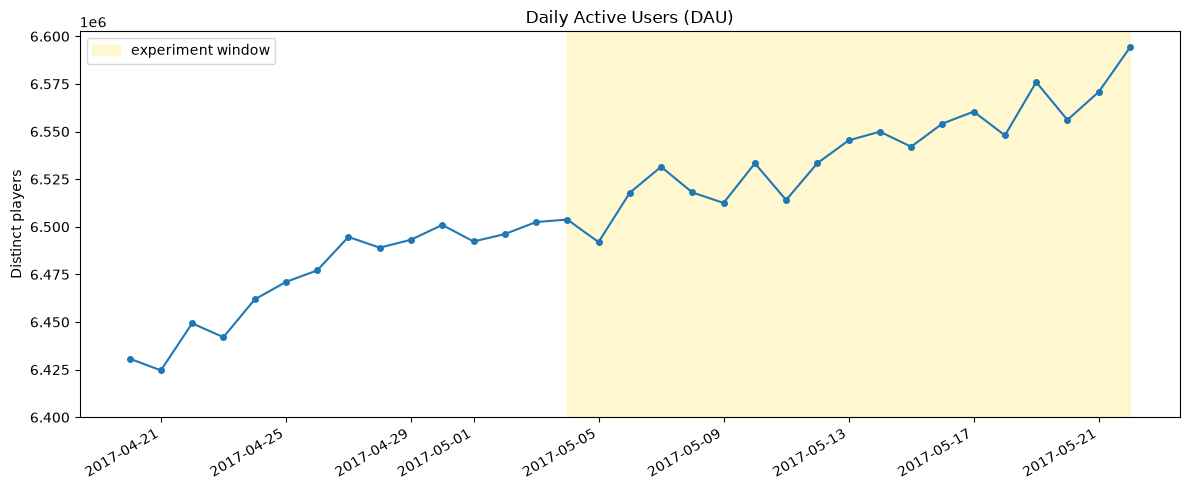

In [3]:
# 2. What is DAU? any trend?

dau = """
SELECT
    activity_date,
    count(distinct playerid) as dau
FROM `king-ds-recruit-candidate-1114.abtest.activity`
GROUP BY activity_date
ORDER BY activity_date
"""
dau_df = run_query(dau, save_as=None)

# activity_date is a STRING in BigQuery -> parse to a real date for a time axis
dau_df["activity_date"] = pd.to_datetime(dau_df["activity_date"])

# experiment window (assignment table spans 2017-05-04 to 2017-05-22)
EXP_START = pd.Timestamp("2017-05-04")
EXP_END = pd.Timestamp("2017-05-22")

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.plot(dau_df["activity_date"], dau_df["dau"], marker="o", markersize=4)
ax.axvspan(EXP_START, EXP_END, color="#FFF3B0", alpha=0.6, label="experiment window")
ax.set_title("Daily Active Users (DAU)")
ax.set_ylabel("Distinct players")
ax.set_ylim(bottom=6.4e6)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


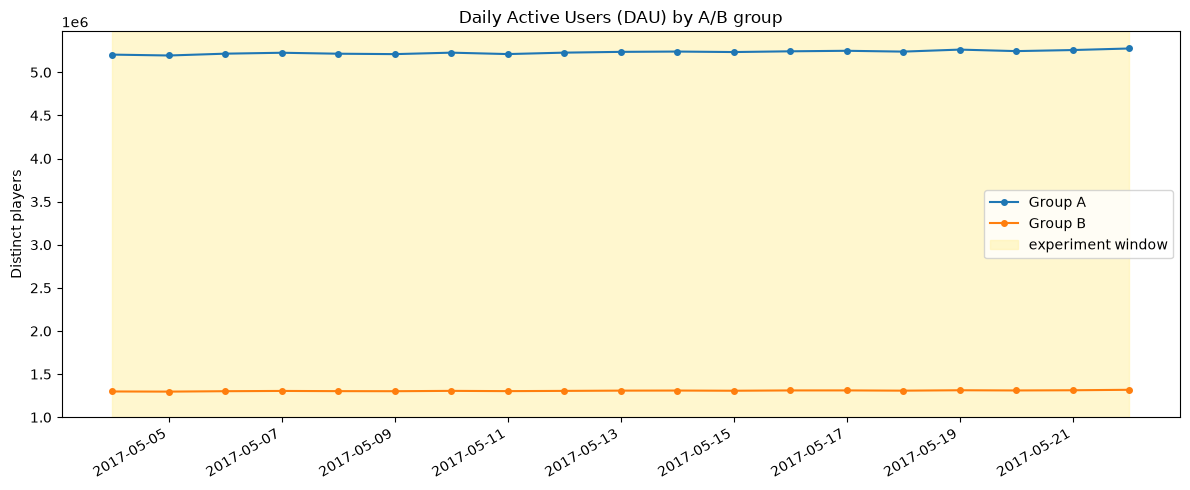

In [ ]:
# 3. What is DAU by A/B groups?

dau_abtest = """
SELECT
    t.activity_date,
    a.abtest_group,
    count(distinct a.playerid) as dau
FROM `king-ds-recruit-candidate-1114.abtest.assignment` a
LEFT JOIN `king-ds-recruit-candidate-1114.abtest.activity` t
    on a.playerid = t.playerid
WHERE t.activity_date >= "2017-05-04"
GROUP BY all
ORDER BY activity_date
"""
dau_abtest_df = run_query(dau_abtest, save_as=None)

# activity_date is a STRING in BigQuery -> parse to a real date for a time axis
dau_abtest_df["activity_date"] = pd.to_datetime(dau_abtest_df["activity_date"])

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
for group, g in dau_abtest_df.groupby("abtest_group"):
    ax.plot(g["activity_date"], g["dau"], marker="o", markersize=4, label=f"Group {group}")
ax.axvspan(EXP_START, EXP_END, color="#FFF3B0", alpha=0.6, label="experiment window")
ax.set_title("Daily Active Users (DAU) by A/B group")
ax.set_ylabel("Distinct players")
ax.set_ylim(bottom=1e6)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


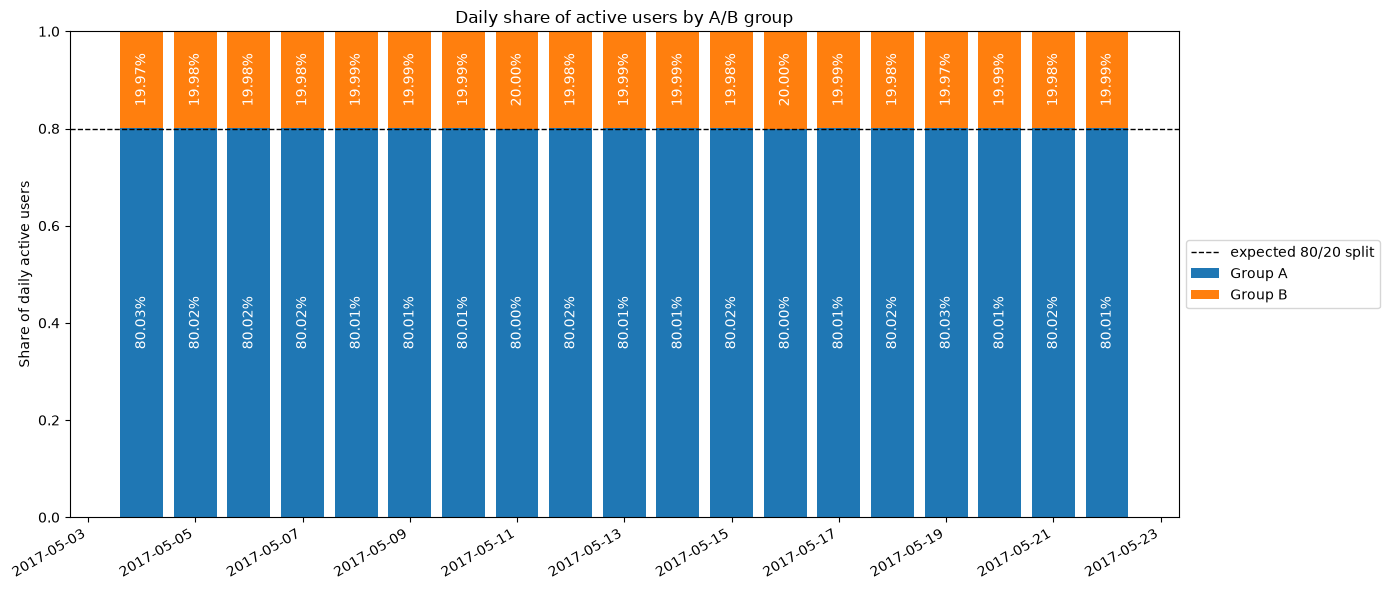

In [13]:
# share of AB users at daily level (SRM sanity check)
# one column per group, then convert each day's counts to shares that sum to 1
pivot = dau_abtest_df.pivot(index="activity_date", columns="abtest_group", values="dau")
share = pivot.div(pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
bottom = np.zeros(len(share))
for group in share.columns:
    vals = share[group].values
    ax.bar(share.index, vals, bottom=bottom, width=0.8, label=f"Group {group}")
    # label each segment with its share as a 2-decimal percentage
    for x, b, v in zip(share.index, bottom, vals):
        ax.text(x, b + v / 2, f"{v * 100:.2f}%", ha="center", va="center",
                rotation=90, fontsize=10, color="white")
    bottom += vals
ax.axhline(0.8, color="black", linestyle="--", linewidth=1, label="expected 80/20 split")
ax.set_title("Daily share of active users by A/B group")
ax.set_ylabel("Share of daily active users")
ax.set_ylim(0, 1)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Observations**:
- DAU kept increasing before the ab test and even during the ab test (+2.6%). So not something the test caused.
- No strong weekly pattern
- **No sign of outbreak / server-down during the test during the ab test period.**
- DAU during the test is around 6.5M while the total number of player base if 10.3M, so nearly 2/3 of users play every day. Stickiness seem too high to be realistic in F2P?. The engagement (later will be seen) that less than 25% of total users in ab test played 0-8 rounds per day (so the rest plays more than 8 rounds), seem too engaged. SYNTHETIC data?
- AB test design ratio is kept closely at 80/20, seem no sign of SRM. But need to check the overal and do a chi-square test later to conclude in the sanity check part.

# Share of player segments 
- new players vs existing players
- non paying players vs spenders
- A and B groups

In [23]:
# "new" = new user when grouped into the test (install_date = assignment_date); else "existing"
# overall: distinct players over the whole period (assignment table, no day double-count)
seg_overall = """
SELECT
    abtest_group,
    CASE WHEN install_date = assignment_date THEN True ELSE False END AS new_user,
    COUNT(DISTINCT playerid) AS no_users
FROM `king-ds-recruit-candidate-1114.abtest.assignment`
GROUP BY all
"""
overall_df = run_query(seg_overall, save_as=None)
overall_df["player_type"] = np.where(overall_df["new_user"], "new", "existing")

# seg at daily level
seg_daily = """
with user_segment as (
SELECT
    t.activity_date,
    t.playerid,
    t.purchases,
    t.gameends,
    a.abtest_group,
    a.install_date,
    a.conversion_date,
    a.assignment_date,
    case when a.assignment_date = a.install_date then True else False end as new_user,
    case
        when conversion_date is null then "non paying player"
        when conversion_date >= assignment_date then "new spender"
        when conversion_date < assignment_date then "existing spender"
        else null
    end as purchase_user_segment
FROM `king-ds-recruit-candidate-1114.abtest.assignment` a
LEFT JOIN `king-ds-recruit-candidate-1114.abtest.activity` t
    on a.playerid = t.playerid
WHERE t.activity_date >= "2017-05-04"
    )

SELECT
    activity_date,
    abtest_group,
    new_user, purchase_user_segment, count(distinct playerid) no_users
FROM user_segment
GROUP BY all
ORDER BY 1,2
"""
daily_df = run_query(seg_daily, save_as=None)
daily_df["activity_date"] = pd.to_datetime(daily_df["activity_date"])
daily_df["player_type"] = np.where(daily_df["new_user"], "new", "existing")

/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### Share of new vs existing players

/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


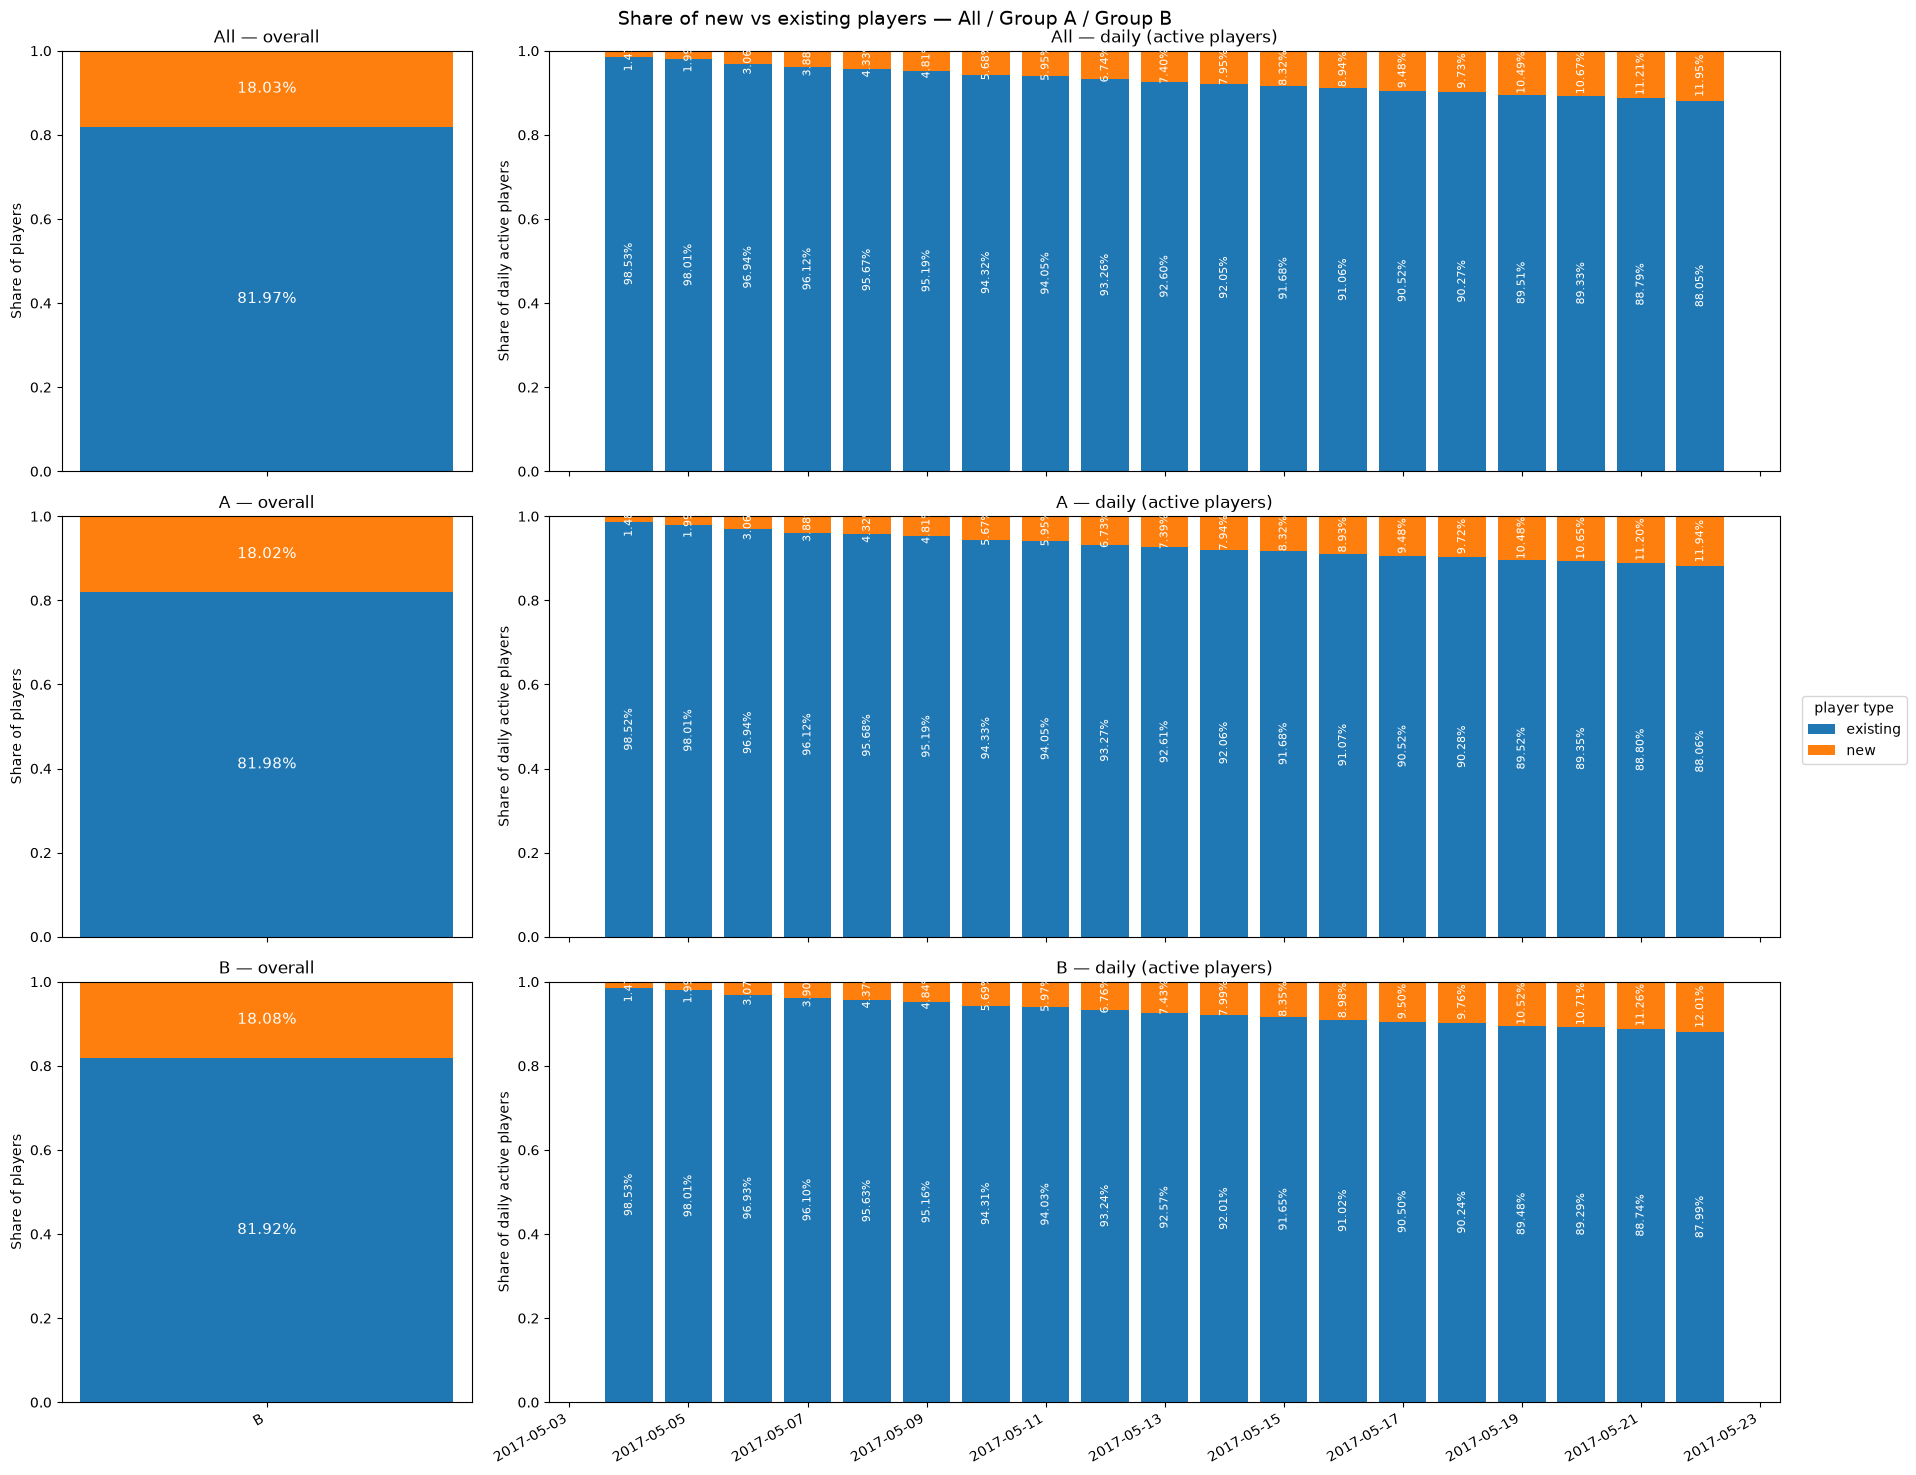

In [ ]:
order = ["existing", "new"]                       # existing at bottom, new on top
colors = {"existing": "C0", "new": "C1"}          # keep colors consistent across all panels
populations = ["All", "A", "B"]

fig, axes = plt.subplots(3, 2, figsize=(18, 15),
                         gridspec_kw={"width_ratios": [1, 3]})
fig.patch.set_facecolor("white")

for row, pop in enumerate(populations):
    ax_all, ax_daily = axes[row, 0], axes[row, 1]
    ax_all.set_facecolor("white")
    ax_daily.set_facecolor("white")

    o = overall_df if pop == "All" else overall_df[overall_df["abtest_group"] == pop]
    d = daily_df if pop == "All" else daily_df[daily_df["abtest_group"] == pop]

    # left: one overall stacked bar (share over the whole period)
    o_share = o.groupby("player_type")["no_users"].sum()
    o_share = o_share / o_share.sum()
    bottom = 0.0
    for seg in order:
        v = o_share.get(seg, 0.0)
        ax_all.bar(pop, v, bottom=bottom, width=0.6, color=colors[seg], label=seg)
        ax_all.text(0, bottom + v / 2, f"{v * 100:.2f}%", ha="center", va="center",
                    fontsize=11, color="white")
        bottom += v
    ax_all.set_title(f"{pop} — overall")
    ax_all.set_ylabel("Share of players")
    ax_all.set_ylim(0, 1)

    # right: daily stacked bars (share of daily active players)
    p_daily = d.groupby(["activity_date", "player_type"])["no_users"].sum().unstack("player_type")
    share_daily = p_daily[order].div(p_daily[order].sum(axis=1), axis=0)
    bottom = np.zeros(len(share_daily))
    for seg in order:
        vals = share_daily[seg].values
        ax_daily.bar(share_daily.index, vals, bottom=bottom, width=0.8, color=colors[seg], label=seg)
        for x, b, v in zip(share_daily.index, bottom, vals):
            ax_daily.text(x, b + v / 2, f"{v * 100:.2f}%", ha="center", va="center",
                          rotation=90, fontsize=8, color="white")
        bottom += vals
    ax_daily.set_title(f"{pop} — daily (active players)")
    ax_daily.set_ylabel("Share of daily active players")
    ax_daily.set_ylim(0, 1)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.0, 0.5), title="player type")
fig.suptitle("Share of new vs existing players — All / Group A / Group B", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


Observations:
- new vs existing mix is balanced between groups
- increasing amount of new users is aligned with increasing of DAU over the whole period.


### Share of spenders and non-paying players

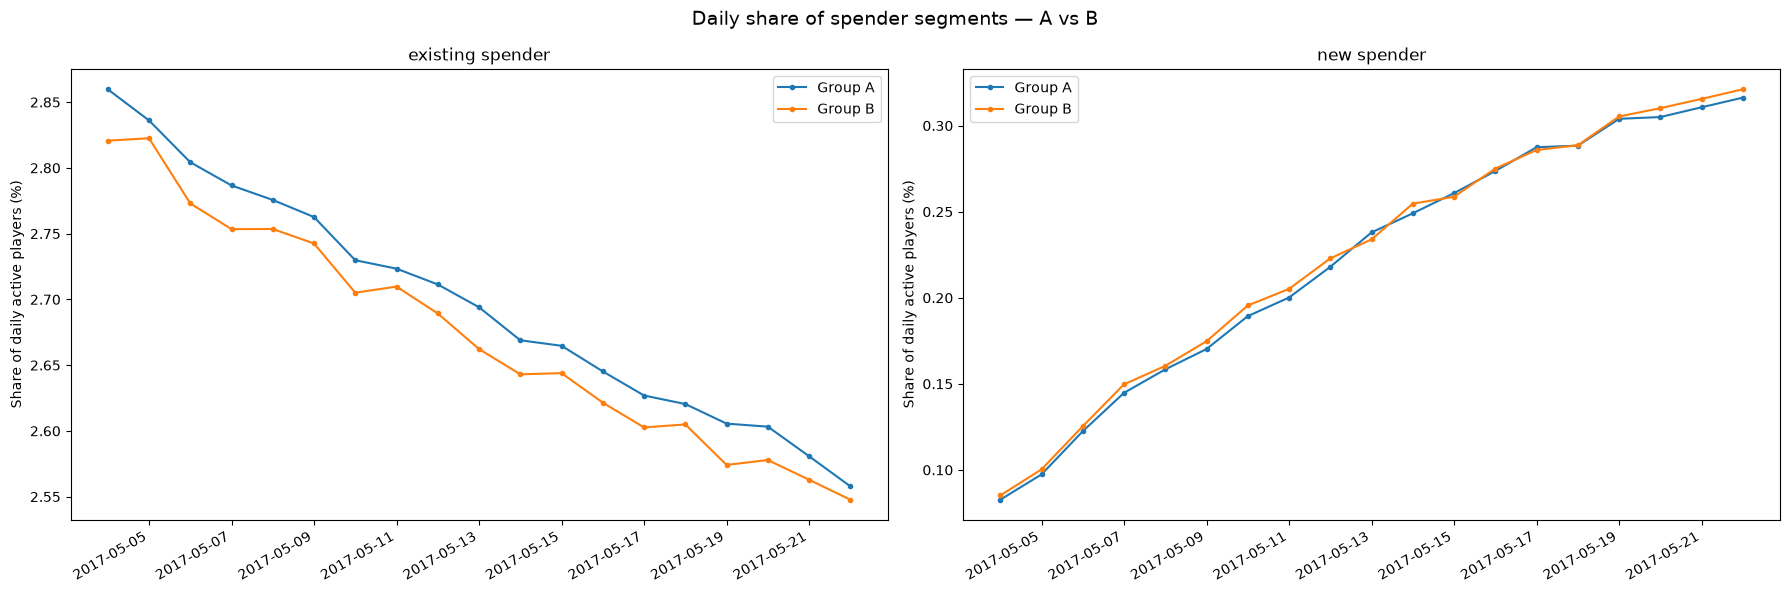

In [28]:
# spenders are a very small % -> line chart (share of daily active players), A vs B
# non-paying is ~97%+ so it's dropped here; we zoom into the spender segments

# daily total active per group, then each segment's share of it (scaled to percent)
totals = daily_df.groupby(["activity_date", "abtest_group"])["no_users"].sum().rename("total")
seg = daily_df.groupby(["activity_date", "abtest_group", "purchase_user_segment"])["no_users"].sum().reset_index()
seg = seg.merge(totals, on=["activity_date", "abtest_group"])
seg["share_pct"] = 100 * seg["no_users"] / seg["total"]

spender_segments = ["existing spender", "new spender"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
fig.patch.set_facecolor("white")
for ax, s in zip(axes, spender_segments):
    ax.set_facecolor("white")
    for grp in ["A", "B"]:
        d = seg[(seg["purchase_user_segment"] == s) & (seg["abtest_group"] == grp)].sort_values("activity_date")
        ax.plot(d["activity_date"], d["share_pct"], marker="o", markersize=3, label=f"Group {grp}")
    ax.set_title(s)
    ax.set_ylabel("Share of daily active players (%)")
    ax.legend()

fig.suptitle("Daily share of spender segments — A vs B", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [39]:
# Existing-spender ratio per group over the whole period (pre-assignment attribute -> balance check)
existing_spender_sql = """
SELECT
    abtest_group,
    COUNT(DISTINCT playerid) AS total_players,
    COUNT(DISTINCT IF(conversion_date < assignment_date, playerid, NULL)) AS existing_spenders,
    100 * COUNT(DISTINCT IF(conversion_date < assignment_date, playerid, NULL))
        / COUNT(DISTINCT playerid) AS existing_spender_pct
FROM `king-ds-recruit-candidate-1114.abtest.assignment`
GROUP BY abtest_group
ORDER BY abtest_group
"""
existing_spender_df = run_query(existing_spender_sql, save_as=None)

# gap between the two arms
gap = existing_spender_df.set_index("abtest_group")["existing_spender_pct"]
print(f"A: {gap['A']:.4f}%   B: {gap['B']:.4f}%   A-B gap: {gap['A'] - gap['B']:+.4f} pp")

existing_spender_df


/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


A: 2.3730%   B: 2.3517%   A-B gap: +0.0213 pp


,abtest_group,total_players,existing_spenders,existing_spender_pct
0,A,8265610,196143,2.373001
1,B,2065446,48573,2.351695


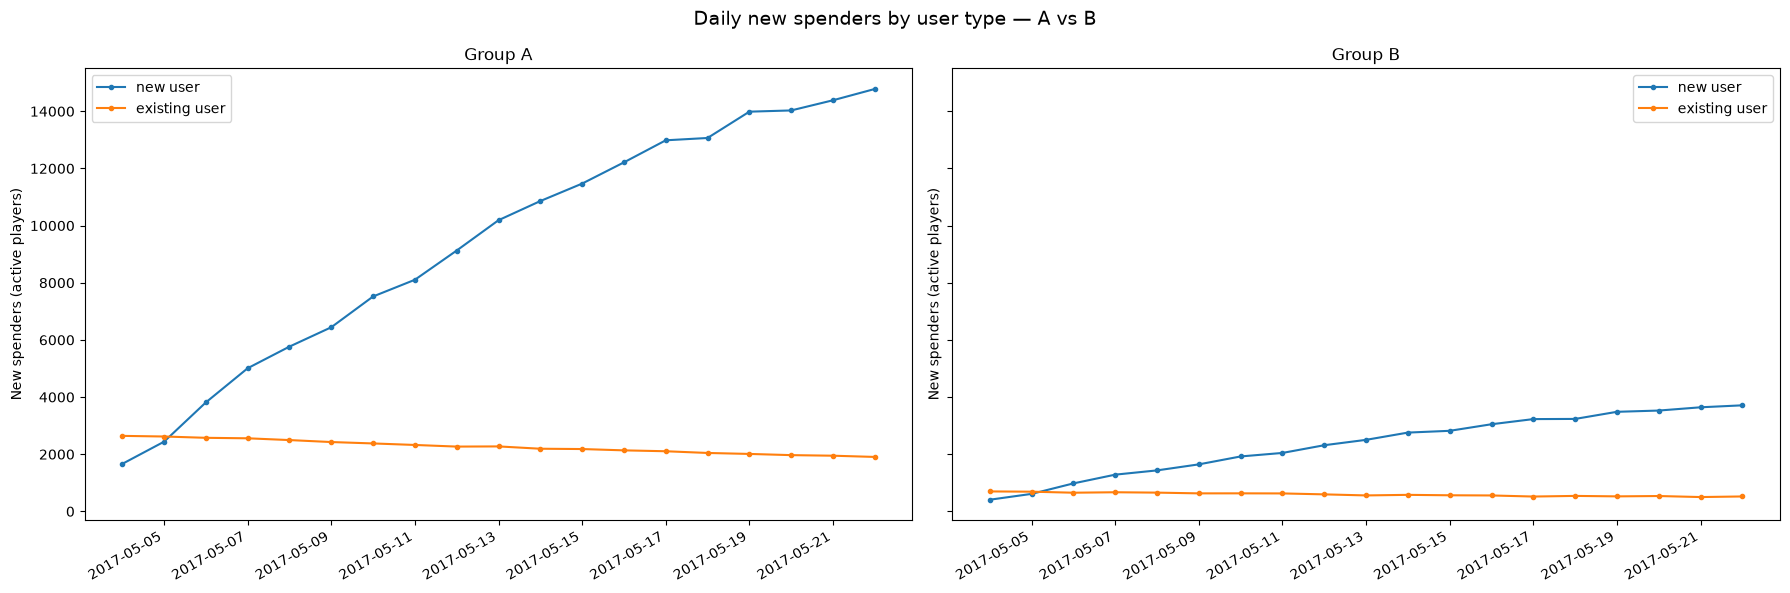

In [38]:
# New-spender daily counts split by user type (new vs existing user), A vs B
# shows the rising new-spender trend is driven by the new-user group
ns = (daily_df[daily_df["purchase_user_segment"] == "new spender"]
      .groupby(["activity_date", "abtest_group", "player_type"])["no_users"].sum().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
for ax, grp in zip(axes, ["A", "B"]):
    ax.set_facecolor("white")
    g = ns[ns["abtest_group"] == grp]
    for ptype in ["new", "existing"]:
        d = g[g["player_type"] == ptype].sort_values("activity_date")
        ax.plot(d["activity_date"], d["no_users"], marker="o", markersize=3, label=f"{ptype} user")
    ax.set_title(f"Group {grp}")
    ax.set_ylabel("New spenders (active players)")
    ax.legend()

fig.suptitle("Daily new spenders by user type — A vs B", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


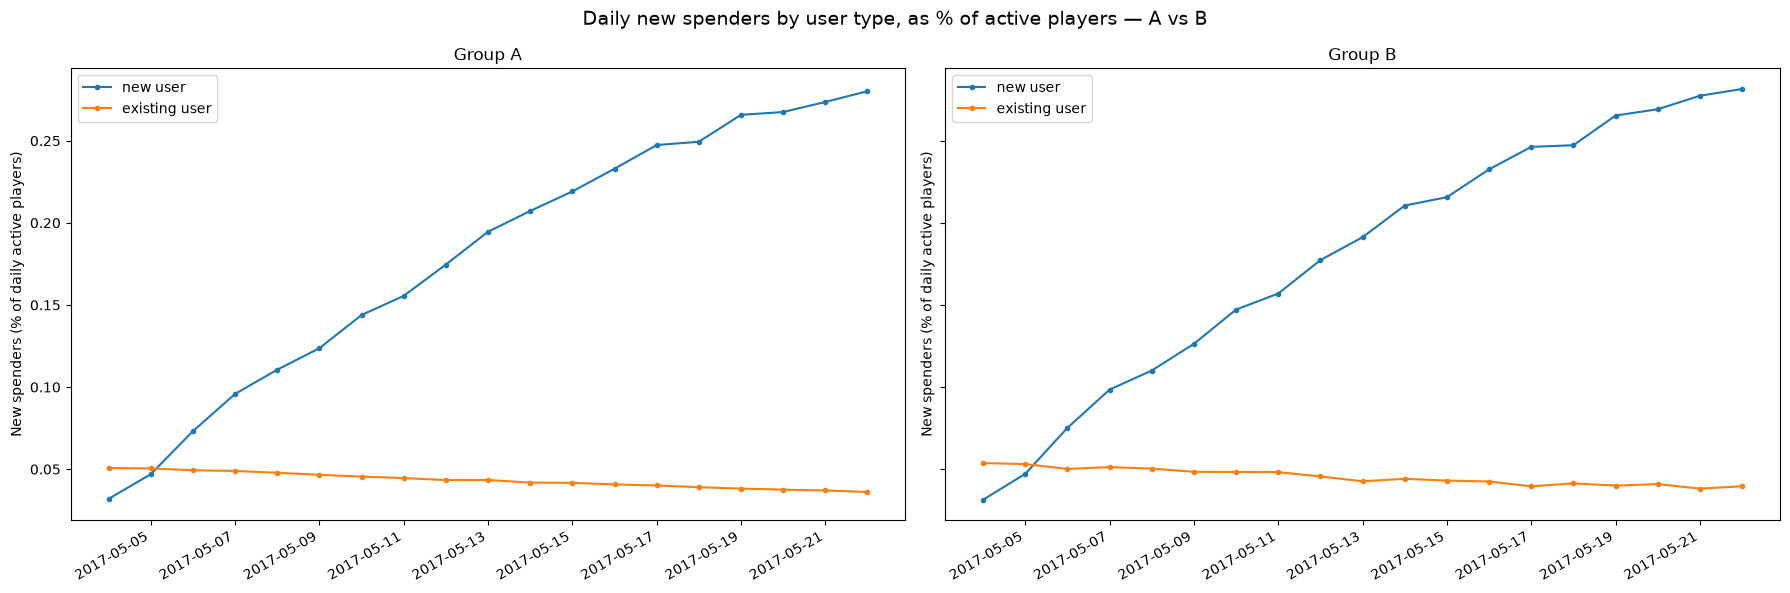

In [40]:
# Same as above but in % of each group's daily active players (A vs B comparable)
ns = (daily_df[daily_df["purchase_user_segment"] == "new spender"]
      .groupby(["activity_date", "abtest_group", "player_type"])["no_users"].sum().reset_index())

# daily active total per group (all segments), to use as denominator
totals = daily_df.groupby(["activity_date", "abtest_group"])["no_users"].sum().rename("total")
ns = ns.merge(totals, on=["activity_date", "abtest_group"])
ns["share_pct"] = 100 * ns["no_users"] / ns["total"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)
fig.patch.set_facecolor("white")
for ax, grp in zip(axes, ["A", "B"]):
    ax.set_facecolor("white")
    g = ns[ns["abtest_group"] == grp]
    for ptype in ["new", "existing"]:
        d = g[g["player_type"] == ptype].sort_values("activity_date")
        ax.plot(d["activity_date"], d["share_pct"], marker="o", markersize=3, label=f"{ptype} user")
    ax.set_title(f"Group {grp}")
    ax.set_ylabel("New spenders (% of daily active players)")
    ax.legend()

fig.suptitle("Daily new spenders by user type, as % of active players — A vs B", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Observations**:
- Existing-spender share is balanced across arms (2.37% vs 2.35%) → no sign of imbalance, like new/existing.
- One intersting thing to keep in mind is the share of existing spenders decreasing over the period time in both groups while the share of new spenders increases. The increase of new spenders share is mainly driven by the new user group and observed in both A control and B treatment. This aligns with the fact that share of new users increases significantly in the end of the test. 

**CONCLUDE**: Exposure is broad and balanced across all user segments. The test targets the general population, in practice dominated by existing non-paying players. What was changed is still open; that comes from the engagement/monetization behaviour next."

# Engagement: Game round and Purchase

In [41]:
# Existing-spender ratio per group over the whole period (pre-assignment attribute -> balance check)
engagament_sql = """
with 
  segment as (
SELECT 
  a.playerid, a.activity_date, a.gameends, a.purchases, r.abtest_group,
  DATE(r.conversion_date) as first_purchase_date,
  DATE(r.install_date) as install_date,
  DATE(r.assignment_date) as abtest_random_date,
  a.gameends as number_game_rounds, 
  a.purchases as number_purchases,
  case when r.install_date = r.assignment_date then "new user" else "existing user" end as player_type,
  case 
    when r.conversion_date is null then "non paying player"
    when r.conversion_date < r.assignment_date then "exising spender"
    when r.conversion_date >= r.assignment_date then "new spender"
    else "NA"
  end as spending_type
FROM `king-ds-recruit-candidate-1114.abtest.activity` a
JOIN `king-ds-recruit-candidate-1114.abtest.assignment` r
  on r.playerid = a.playerid
  )

SELECT
  activity_date,
  abtest_group,
  count(distinct playerid) as total_players, --- for the pre-test period, only incl. only the ones in the ab test later
  round(sum(number_game_rounds)/count(distinct playerid),2) as avg_gameround_per_player,
  round(sum(case when number_purchases > 0  then number_game_rounds end)/count(distinct case when number_purchases > 0 then playerid end),2) as avg_gameround_per_paying_player,
  round(sum(case when player_type = "existing user" then number_game_rounds end)/count(distinct case when player_type = "existing user" then playerid end),2) as avg_gameround_per_existing_player,
  round(sum(case when player_type = "new user" then number_game_rounds end)/count(distinct case when player_type = "new user" then playerid end),2) as avg_gameround_per_new_player,
  round(sum(case when spending_type = "non paying player" then number_game_rounds end)/count(distinct case when spending_type = "non paying player" then playerid end),2) as avg_gameround_per_nonpaying_player,
  round(sum(case when spending_type = "exising spender" then number_game_rounds end)/count(distinct case when spending_type = "exising spender" then playerid end),2) as avg_gameround_per_existing_spender,
  round(sum(case when spending_type = "new spender" then number_game_rounds end)/count(distinct case when spending_type = "new spender" then playerid end),2) as avg_gameround_per_new_spender,
  round(100*count(distinct case when number_purchases > 0 then playerid end)/count(distinct playerid),2) as purchase_rate_pct,
  round(sum(number_purchases)/count(distinct playerid),2) as avg_number_purchase_per_player,
  round(sum(case when number_purchases > 0  then number_purchases end)/count(distinct case when number_purchases > 0 then playerid end),2) as avg_purchase_per_paying_player,
  round(sum(case when number_purchases > 0  and player_type = "existing user" then number_purchases end)/count(distinct case when number_purchases > 0  and player_type = "existing user" then playerid end),2) as avg_purchase_per_existing_player_paying,
  round(sum(case when number_purchases > 0  and player_type = "new user" then number_purchases end)/count(distinct case when number_purchases > 0  and player_type = "new user" then playerid end),2) as avg_purchase_per_new_player_paying,
  round(sum(case when spending_type = "exising spender" then number_purchases end)/count(distinct case when spending_type = "exising spender" then playerid end),2) as avg_purchase_per_existing_spender,
  round(sum(case when spending_type = "new spender" then number_purchases end)/count(distinct case when spending_type = "new spender" then playerid end),2) as avg_purchase_per_new_spender,
FROM segment
GROUP BY all
"""
engagament_df = run_query(engagament_sql, save_as=None)

/Users/trang/Desktop/King_home_assignment/.venv/lib/python3.14/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### Game rounds

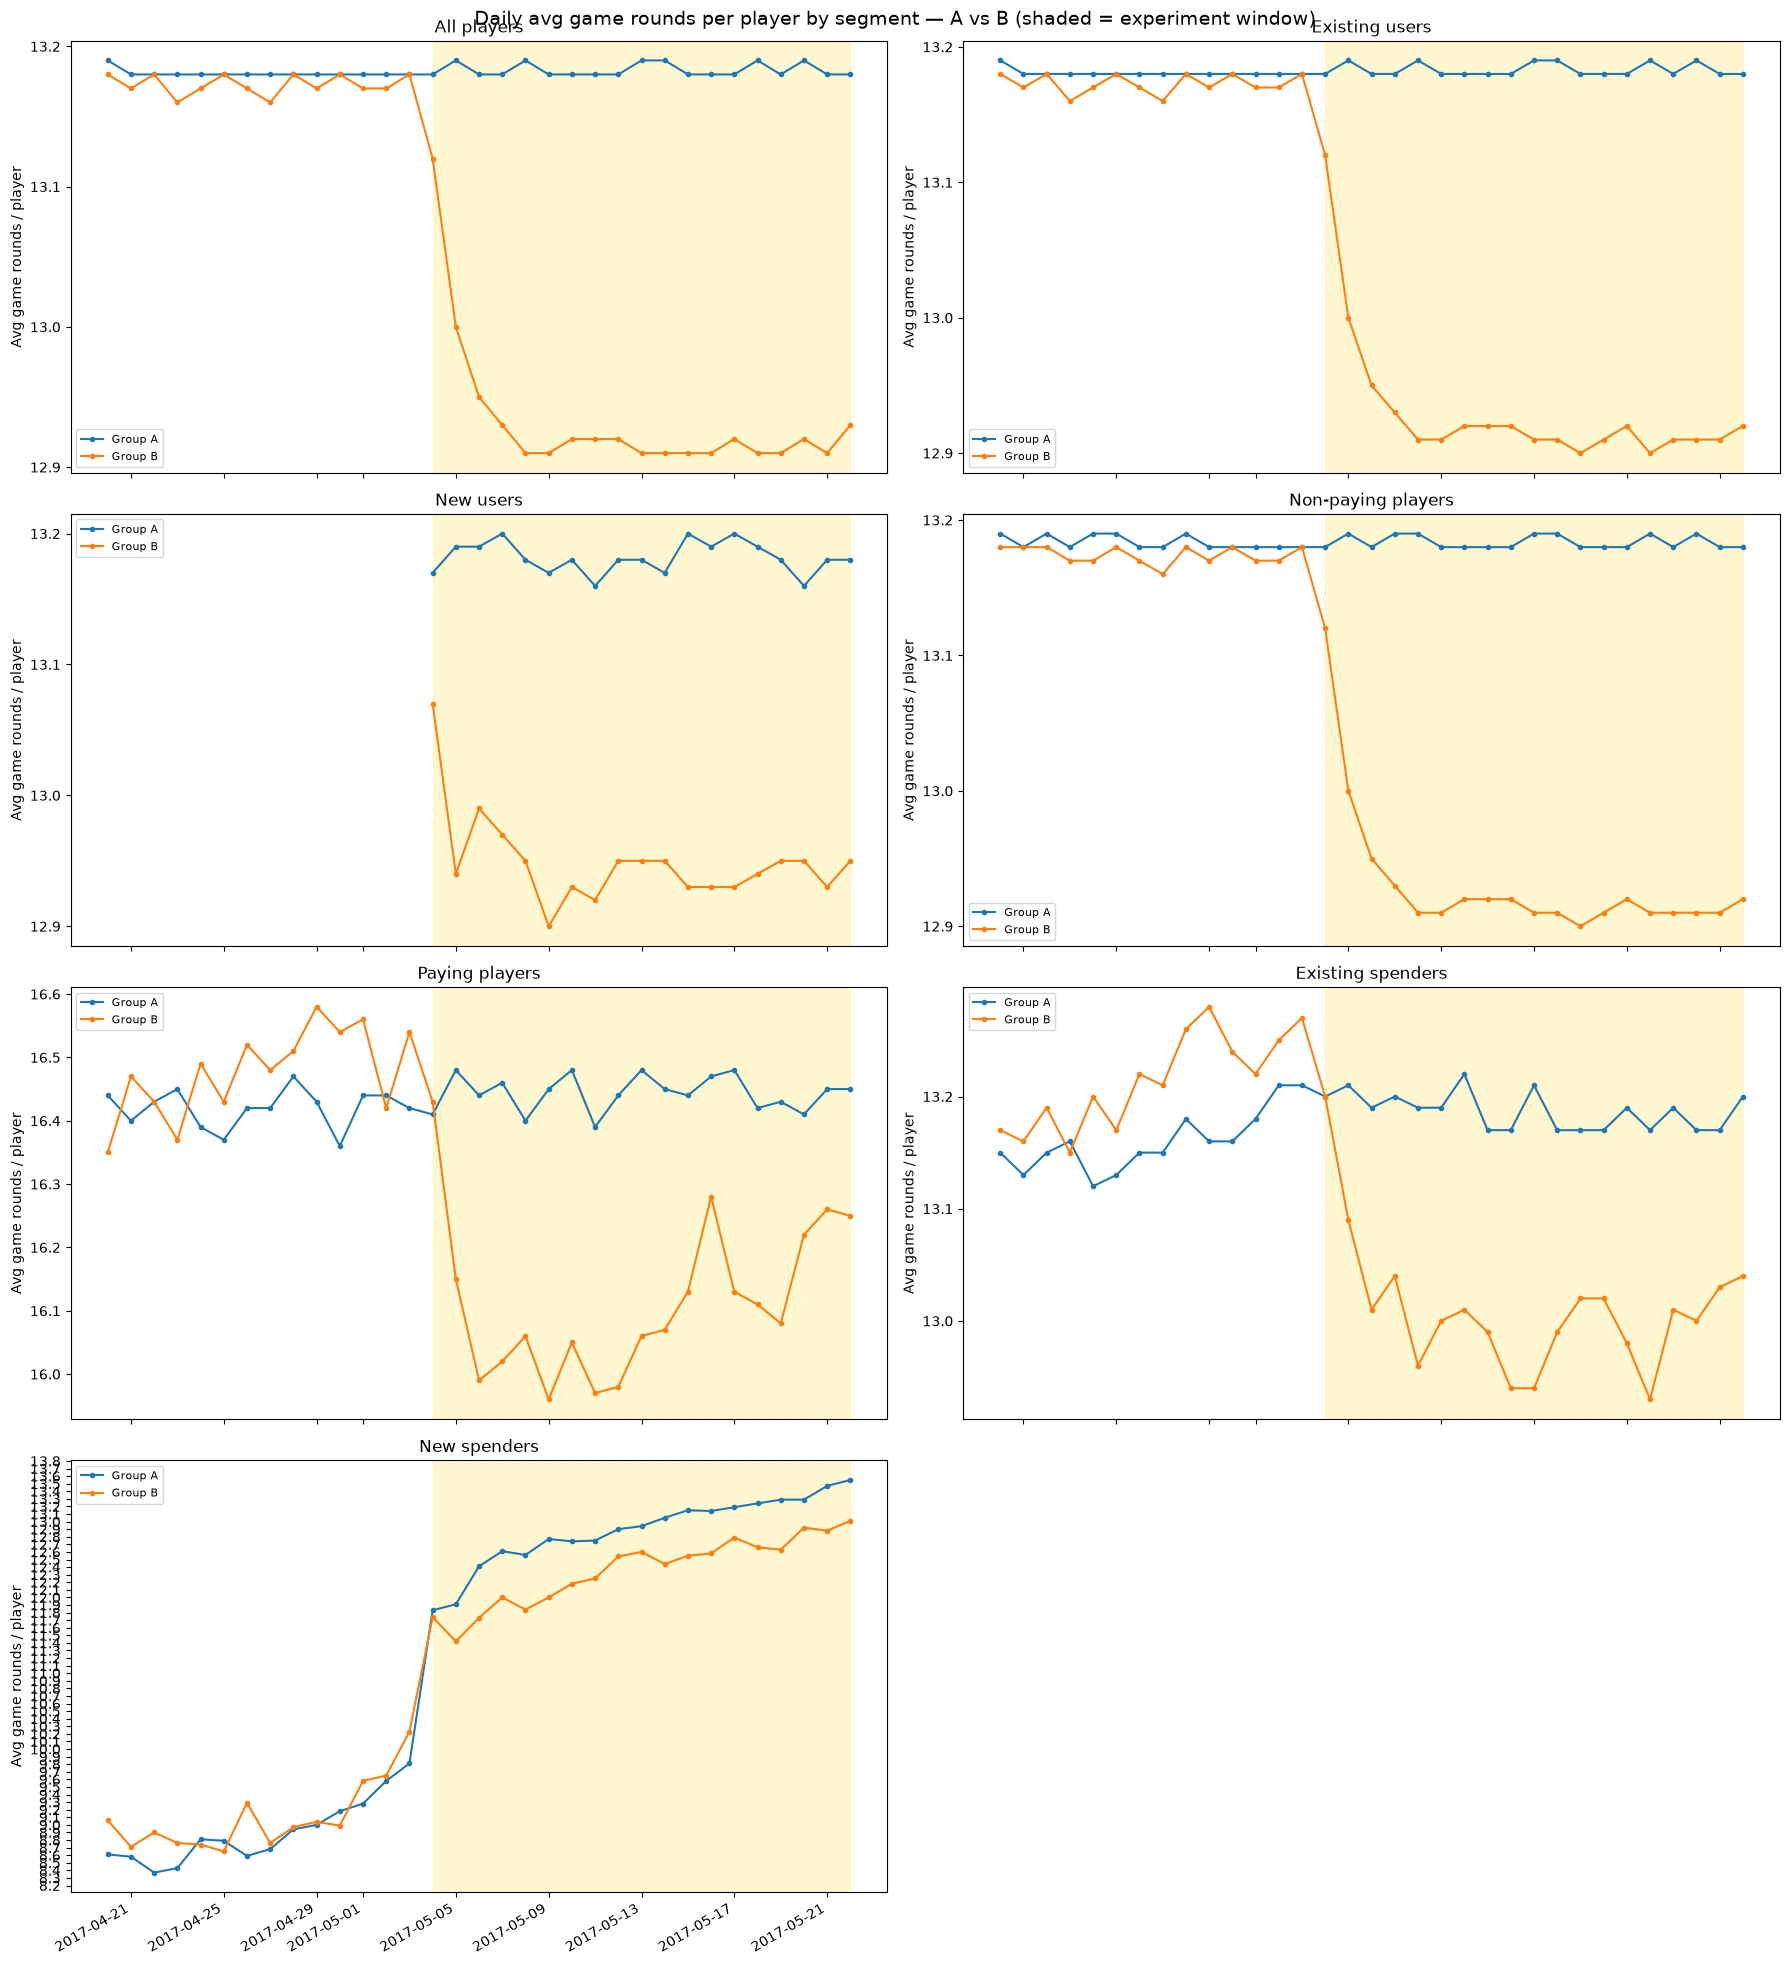

In [ ]:
# Avg game rounds per player, daily trend by segment, A vs B
engagament_df["activity_date"] = pd.to_datetime(engagament_df["activity_date"])
EXP_START, EXP_END = pd.Timestamp("2017-05-04"), pd.Timestamp("2017-05-22")

segments = {
    "avg_gameround_per_player":            "All players",
    "avg_gameround_per_existing_player":   "Existing users",
    "avg_gameround_per_new_player":        "New users",
    "avg_gameround_per_nonpaying_player":  "Non-paying players",
    "avg_gameround_per_paying_player":     "Paying players",
    "avg_gameround_per_existing_spender":  "Existing spenders",
    "avg_gameround_per_new_spender":       "New spenders",
}

fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True)
fig.patch.set_facecolor("white")
axes = axes.ravel()
for ax, (col, title) in zip(axes, segments.items()):
    ax.set_facecolor("white")
    for grp in ["A", "B"]:
        d = engagament_df[engagament_df["abtest_group"] == grp].sort_values("activity_date")
        ax.plot(d["activity_date"], d[col], marker="o", markersize=3, label=f"Group {grp}")
    ax.axvspan(EXP_START, EXP_END, color="#FFF3B0", alpha=0.6)
    ax.set_title(title)
    ax.set_ylabel("Avg game rounds / player")
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.legend(fontsize=8)
# hide the unused 8th panel
for ax in axes[len(segments):]:
    ax.set_visible(False)

fig.suptitle("Daily avg game rounds per player by segment — A vs B (shaded = experiment window)", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Observations:**
- After May 4, the treatment arm (B) plays ~0.25 fewer game rounds/player (~1.9%) than control (A), uniformly across all segments; A is flat and the group were identical pre-test → a broad engagement effect from the treatment.
- Direction hints at a change to the game's difficulty/level mechanic, but rounds can be completed a level or just a round incl not finishing a level. If it is a completed level, fewer rounds could mean the game is more difficult so users pass less levels. This could build up frustuation later to impact long term retention. If it is just a playing round incl. not finishing a level, fewer rounds could mean it is an easier game (fewer retries) so users retries less. This can make users feel bored in long term and quit.

Let's look at the purchase to see which direction the purchase data support.

### Purchase

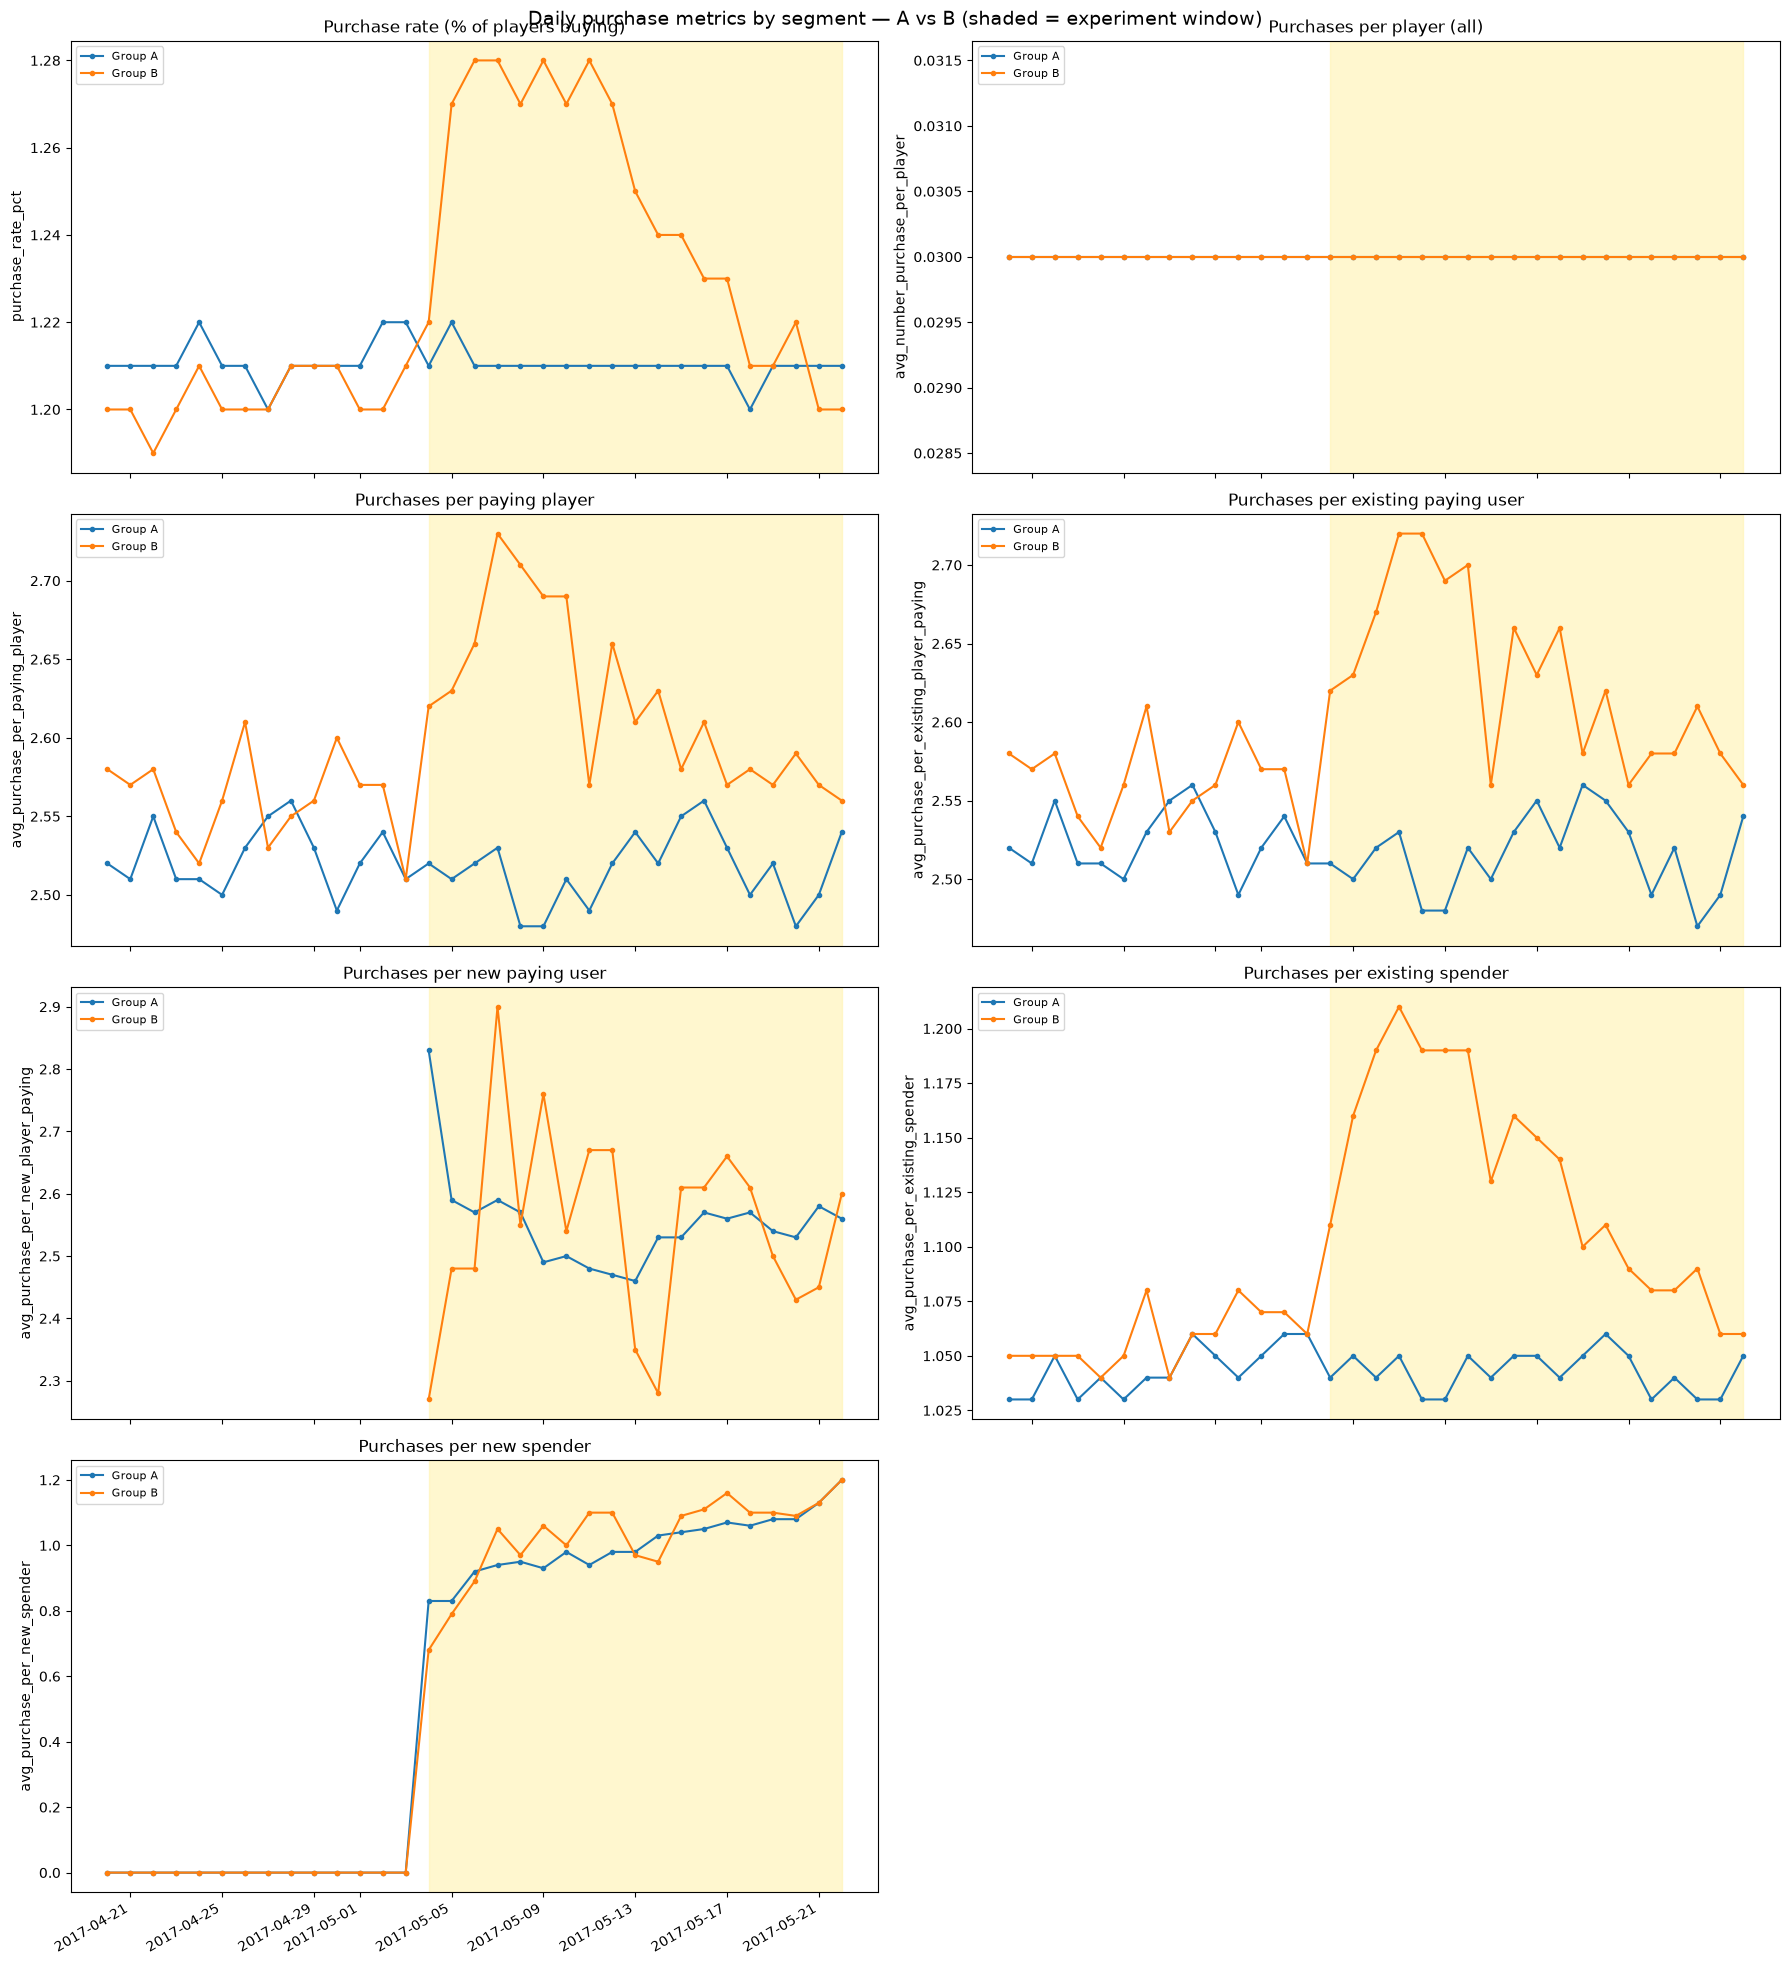

In [44]:
# Purchase metrics, daily trend by segment, A vs B
engagament_df["activity_date"] = pd.to_datetime(engagament_df["activity_date"])
EXP_START, EXP_END = pd.Timestamp("2017-05-04"), pd.Timestamp("2017-05-22")

purchase_metrics = {
    "purchase_rate_pct":                      "Purchase rate (% of players buying)",
    "avg_number_purchase_per_player":         "Purchases per player (all)",
    "avg_purchase_per_paying_player":         "Purchases per paying player",
    "avg_purchase_per_existing_player_paying":"Purchases per existing paying user",
    "avg_purchase_per_new_player_paying":     "Purchases per new paying user",
    "avg_purchase_per_existing_spender":      "Purchases per existing spender",
    "avg_purchase_per_new_spender":           "Purchases per new spender",
}

fig, axes = plt.subplots(4, 2, figsize=(18, 20), sharex=True)
fig.patch.set_facecolor("white")
axes = axes.ravel()
for ax, (col, title) in zip(axes, purchase_metrics.items()):
    ax.set_facecolor("white")
    for grp in ["A", "B"]:
        d = engagament_df[engagament_df["abtest_group"] == grp].sort_values("activity_date")
        ax.plot(d["activity_date"], d[col], marker="o", markersize=3, label=f"Group {grp}")
    ax.axvspan(EXP_START, EXP_END, color="#FFF3B0", alpha=0.6)
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
for ax in axes[len(purchase_metrics):]:
    ax.set_visible(False)

fig.suptitle("Daily purchase metrics by segment — A vs B (shaded = experiment window)", fontsize=14)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Observation**
- Before the AB test was started, the purchase behaviour of users in both group A and B are quite identical, incl. purchase rate, average number of purchase per player and per paying player. After the AB test was started, the purchase rate for Treatment group was jumpting from 1.21% to 1.28%, staying in the peak for a while before decreasing back to the original rate by end of the test while the purchase rate for Control group was still stable around 1.21% comparing to the pre-test. Similarly, the average number of purchase per paying use observed the same pattern increasing first and then decreasing back in the treatment group while for Control group, the trend is more or less stable throughout the whole period before and during the test. If we take out the existing users who were active both before the test and during the test, the observation is same for players in group B and players in group A. 
- For the new user group, the average number of purchase per paying new user is quite fluctuated in both groups and no clear difference is observed here. One explaination for this is due to a small sample size: number of new users who pay at least one time during the test.
- For the new spender group - which can be new players and converted during the test or existing player moving from non-paying to paying state, the average number of purschase per new spender was increasing during the AB test both Control and Treatment group (from 0.8 to 1.2). The treatment one at first seems to have higher trend line but in the end of the test, it converged with the Control group

Novelty effect is clearly observed in both purchase rate and average number of purchase metrics in at overall and # segments.

So, this clearly indicates the side of the game is harder in the treatment group that users, especially the existing spenders buy more hints to pass the level. This makes their number of rounds decreased. 

# CONCLUSION

**Game context:**

Insight / rationale: the game is F2P and ~97% of active players never purchase; monetization comes almost entirely from hint purchases made to get past levels players can't beat. So anything that makes players more reliant on paid hints to progress is a lever on revenue.

**Hypothesis:**

Because hint demand rises when players struggle to progress unaided, we believe the treatment will increase purchases per player vs. control, while keeping the engagement cost (rounds) and retention small enough not to harm the player base.
Formal statement (primary metric = purchases per player, proxy for revenue per user):

- H₀ (null): The new experience has no effect on purchases per player vs. control (B − A = 0).
- H₁ (alternative): The new experience increases purchases per player vs. control (B − A > 0), one-sided.

Note: Treatment (what changed — inferred, not identifiable exactly): Control B received a change that increases the need to buy hints to keep progressing. The data can't distinguish the specific implementation — candidates include harder levels/question selection, fewer or less effective free hints, or tighter move/time limits. All are consistent with the observed signature (rounds ↓, hint purchases ↑).

**Metrics**

1. Primary metric: purchases per player: expected to be higher in B
2. Guardrail metrics:
- game rounds per player: not meaningfully lower in B (a small drop is acceptable; a large one is not).
- 7-day retention: not lower in B (protects long-term player base against frustration/churn).
3. Secondary metrics:
- purchase rate (% buying) 
- average number of purchases per spender: higher in B, confirming the hint-buying mechanism.

**Decision rule**

Decision rule (write before testing): Ship B only if the primary metric shows a statistically significant, sustained lift and no guardrail (rounds, retention) shows a meaningful decline. A lift that exists only in the first week (novelty) or comes with a retention drop → do not ship.

**NOTE:** No sign of SRM (80/20 split and segment balance hold). Clear novelty effect on purchases — the B lift peaks in week 1 and decays to ~0 by the last week — while the engagement effect (fewer rounds in B) persists through the whole window. So by end of test, B carries the engagement cost without the purchase gain.